In [12]:
import pandas as pd
import pickle
import os
import sys
import numpy as np

In [13]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

# Import pickle operations

from pickle_file_operations import read_pickle, write_pickle
from optimization_dataclasses import Optimization_Results
# pd.set_option('display.float_format', '{:.4f}'.format)

In [14]:
folders = ["Unconstrained model", "Constrained model", "FICNN model"]

In [15]:
history_dict = {}
for folder in folders:
    history_path = os.path.join(cwd, "NN width models", folder)
    history_pickle = read_pickle(os.path.join(history_path, "history_dict.pickle"))
    history_dict[folder] = history_pickle

history_dict

{'Unconstrained model': {'half': <keras.src.callbacks.history.History at 0x23b0e030e30>,
  'two': <keras.src.callbacks.history.History at 0x23b0e030b90>,
  'five': <keras.src.callbacks.history.History at 0x23b0e032f00>,
  'ten': <keras.src.callbacks.history.History at 0x23b1022ffb0>},
 'Constrained model': {'half': <keras.src.callbacks.history.History at 0x23b102b4fe0>,
  'two': <keras.src.callbacks.history.History at 0x23b1039c830>,
  'five': <keras.src.callbacks.history.History at 0x23b1092fd40>,
  'ten': <keras.src.callbacks.history.History at 0x23b1039c7d0>},
 'FICNN model': {'half': <keras.src.callbacks.history.History at 0x23b101c3b00>,
  'two': <keras.src.callbacks.history.History at 0x23b101eea20>,
  'five': <keras.src.callbacks.history.History at 0x23b10af3f80>,
  'ten': <keras.src.callbacks.history.History at 0x23b101ecd10>}}

In [16]:
from matplotlib import pyplot as plt

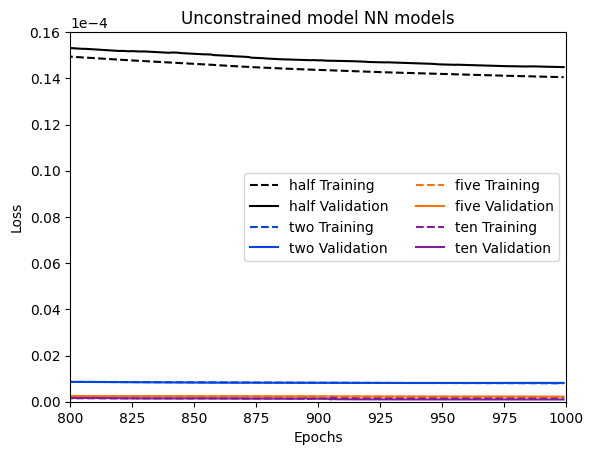

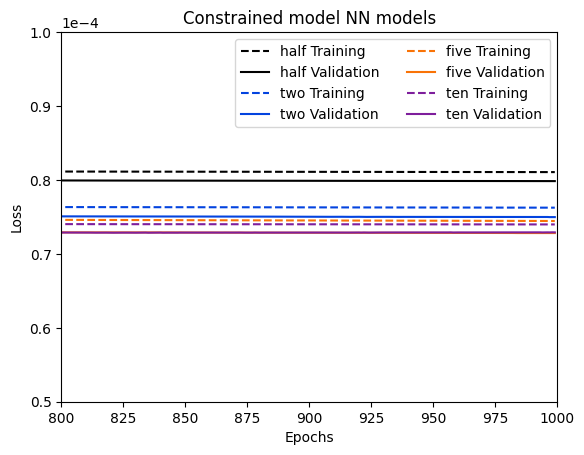

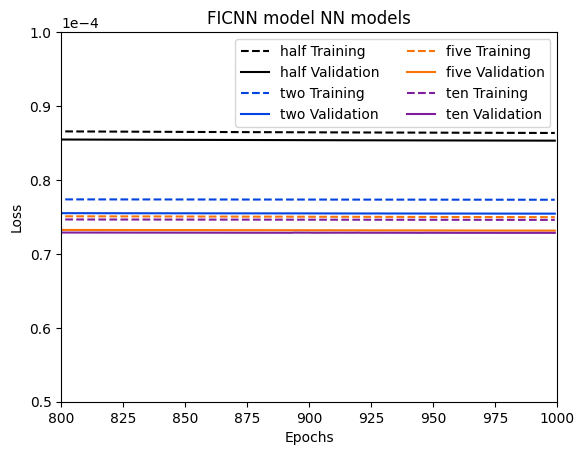

In [17]:
color_names = ["black", "blue", "orange", "purple", "green", "red"]
colors = ["xkcd:"+color_name for color_name in color_names]
for idx, (folder, histories) in enumerate(history_dict.items()):
    for i, (key, history) in enumerate(histories.items()):
        plt.plot(history.history['loss'], label=key+" Training", linestyle="--", color=colors[i])
        plt.plot(history.history['val_loss'], label=key+ " Validation", color=colors[i])

    plt.ticklabel_format(axis='y', style='sci', scilimits=(-4, -4))
    plt.title(folder + " NN models")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xlim([800, 1000])
    if idx == 0:
        plt.ylim([0, 0.000016])
    else:
        plt.ylim([0.00005, 0.0001])
    plt.legend(ncols=2)
    plt.show()

In [18]:
rmse_dict = {}
key_names = {"half": 0.5, "two": 2, "five": 5, "ten": 10}
for idx, (folder, histories) in enumerate(history_dict.items()):
    rmse_dict[folder] = {}
    for i, (key, history) in enumerate(histories.items()):
        rmse = history.history["loss"][-1]**0.5 * 741.868
        key_name = key_names[key]
        rmse_dict[folder][key_name] = rmse

In [19]:
rmse_dict

{'Unconstrained model': {0.5: 2.7808188265421276,
  2: 0.6628740572204207,
  5: 0.3438051411823632,
  10: 0.27106124272374504},
 'Constrained model': {0.5: 6.679402072468924,
  2: 6.478182961975709,
  5: 6.401176380991935,
  10: 6.38110034078357},
 'FICNN model': {0.5: 6.894032290445905,
  2: 6.523516094725595,
  5: 6.423426229315995,
  10: 6.407563193249034}}

In [20]:
def get_expected_rmse(row):
    model = row['model']
    width = row['width']
    return rmse_dict[model][width]

In [34]:
summary_tables = read_pickle("width_summmary_tables.pickle")
# summary_tables = summary_tables[summary_tables["infeasible"] == False]
# print(summary_tables)
rmse_table = (summary_tables.groupby(["width", "methodology"])["mean_square_error"].mean()) **0.5
rmse_table = rmse_table.reset_index()
rmse_table['model'] = np.where(
    rmse_table['methodology'] == 'ICNN 1',
    'Constrained model',
    np.where(
        rmse_table['methodology'] == 'ICNN 2',
        'FICNN model',
        'Unconstrained model'
    )
)
rmse_table["expected_rmse"] = rmse_table.apply(get_expected_rmse, axis = 1)

In [35]:
rmse_table.groupby(["width", "methodology"])[["mean_square_error", "expected_rmse"]].sum()

mean_square_error  expected_rmse
width methodology                                 
0.5   Gurobi ML            2.338114       2.780819
      ICNN 1               6.013137       6.679402
      ICNN 2               5.545758       6.894032
      PCAR                22.702238       2.780819
      PCTAR               22.702238       2.780819
2.0   Gurobi ML             7.82301       0.662874
      ICNN 1               5.305926       6.478183
      ICNN 2                4.97004       6.523516
      PCAR                42.257045       0.662874
      PCTAR               42.257045       0.662874
5.0   Gurobi ML           19.039494       0.343805
      ICNN 1               5.209672       6.401176
      ICNN 2               5.334001       6.423426
      PCAR                27.448852       0.343805
      PCTAR               27.448852       0.343805
10.0  Gurobi ML             2.56541       0.271061
      ICNN 1               5.046045       6.381100
      ICNN 2               5.586089       6.407563
      PCAR                17.862115       0.271061
      PCTAR               14.181967       0.271061

In [67]:
df = rmse_table
df.loc[df["methodology"] == "ICNN 2", "methodology"] = "ICNN"

In [68]:
rmse_table

,width,methodology,mean_square_error,model,expected_rmse
0,0.5,Gurobi ML,2.338114,Unconstrained model,2.780819
1,0.5,ICNN 1,6.013137,Constrained model,6.679402
2,0.5,ICNN,5.545758,FICNN model,6.894032
3,0.5,PCAR,22.702238,Unconstrained model,2.780819
4,0.5,PCTAR,22.702238,Unconstrained model,2.780819
5,2.0,Gurobi ML,7.82301,Unconstrained model,0.662874
6,2.0,ICNN 1,5.305926,Constrained model,6.478183
7,2.0,ICNN,4.97004,FICNN model,6.523516
8,2.0,PCAR,42.257045,Unconstrained model,0.662874
9,2.0,PCTAR,42.257045,Unconstrained model,0.662874


In [81]:
colors = ['xkcd:purple', 'xkcd:orange', 'xkcd:blue', 'xkcd:red', "xkcd:dark gray"]
plot_order = ["Gurobi ML", "PCTAR", "PCAR", 
              # "ICNN 1", 
              "ICNN"]

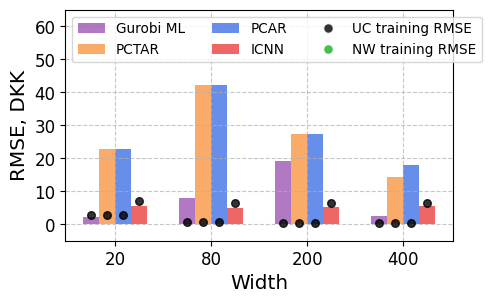

In [79]:
# Plotting
plt.figure(figsize=(5, 3))

# Set bar width and position
bar_width = 1/6
x_positions = np.arange(len(rmse_table['width'].unique()))
handles = []
# Create separate bars for each methodology
for i, methodology in enumerate(plot_order):
    if methodology == "NWLP":
        color_dot = "xkcd:green"
    else:
        color_dot = "xkcd:black"
    subset = rmse_table[rmse_table['methodology'] == methodology]
    bar_positions = x_positions + ((i - 1) * bar_width)  # Shift bars for each methodology
    # plt.bar(bar_positions, subset['mean_square_error'], width=bar_width, label=methodology, alpha=0.6)
    bars = plt.bar(bar_positions, subset['mean_square_error'], width=bar_width, label=methodology, zorder=1, alpha=0.6, color=colors[i])
    handles.append(bars)

    # Annotate expected RMSE values on top of each bar as dots
    for bar, expected_rmse in zip(bars, subset['expected_rmse']):
        yval = bar.get_height()
        plt.scatter(bar.get_x() + bar.get_width() / 2, expected_rmse, color=color_dot, s=30, zorder=5, marker="o", alpha=0.8)  # Red dots above bars
    
# Adding labels and title
plt.xlabel('Width', fontsize="x-large")
plt.ylabel('RMSE, DKK', fontsize="x-large")
plt.xticks(x_positions + bar_width / 2, [round(40 * x) for x in rmse_table['width'].unique()], fontsize="large")  # Center the x-ticks
plt.yticks(fontsize="large")
plt.ylim([-5, 65])
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

# Add a custom legend for expected RMSE levels

expected_rmse_patch_1 = plt.Line2D([0], [0], marker='o', color='w', label='UC training RMSE',
                                   markerfacecolor='xkcd:black', markersize=7, alpha=0.8)
handles.append(expected_rmse_patch_1)
expected_rmse_patch_2 = plt.Line2D([0], [0], marker='o', color='w', label='NW training RMSE',
                                   markerfacecolor='xkcd:green', markersize=7, alpha=0.8)
handles.append(expected_rmse_patch_2)
plt.legend(ncols=3, handles = handles, loc="upper left", fontsize=9.8)
plt.savefig(os.path.join(cwd, "images", "width_rmse_plot.pdf"), bbox_inches="tight")
plt.show()

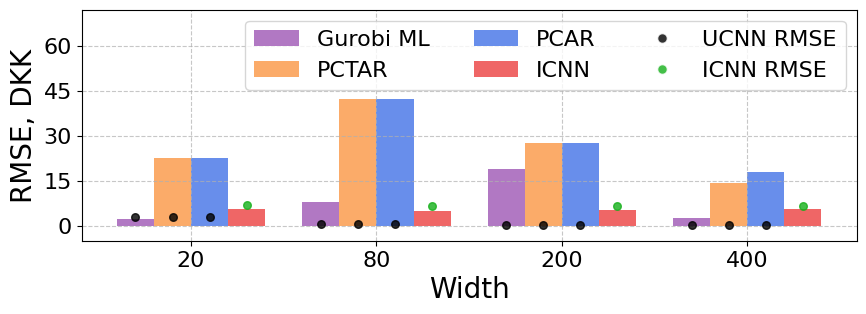

In [85]:
# Plotting
plt.figure(figsize=(10, 3))

# Set bar width and position
bar_width = 0.20
x_positions = np.arange(len(rmse_table['width'].unique()))
handles = []
y_labels = []
# Create separate bars for each methodology
for i, methodology in enumerate(plot_order):
    if methodology == "ICNN":
        color_dot = "xkcd:green"
    else:
        color_dot = "xkcd:black"
        
    new_label = methodology
    # y_labels.append(new_label)
    subset = rmse_table[rmse_table['methodology'] == methodology]
    bar_positions = x_positions + ((i - 1) * bar_width)  # Shift bars for each methodology
    # plt.bar(bar_positions, subset['mean_square_error'], width=bar_width, label=methodology, alpha=0.6)
    bars = plt.bar(bar_positions, subset['mean_square_error'], width=bar_width, label=new_label, zorder=1, alpha=0.6, color=colors[i])
    handles.append(bars)

    # Annotate expected RMSE values on top of each bar as dots
    for bar, expected_rmse in zip(bars, subset['expected_rmse']):
        yval = bar.get_height()
        plt.scatter(bar.get_x() + bar.get_width() / 2, expected_rmse, color=color_dot, s=30, zorder=5, marker="o", alpha=0.8)  # Red dots above bars
    
# Adding labels and title
plt.xlabel('Width', fontsize=20)
plt.ylabel('RMSE, DKK', fontsize=20)
plt.xticks(x_positions + bar_width / 2, [round(40 * x) for x in rmse_table['width'].unique()], fontsize=16)  # Center the x-ticks
plt.yticks([15 * i for i in range(6)], fontsize=16)
plt.ylim([-5, 72])
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

# Add a custom legend for expected RMSE levels
expected_rmse_patch_1 = plt.Line2D([0], [0], marker='o', color='w', label='UCNN RMSE',
                                   markerfacecolor='xkcd:black', markersize=7, alpha=0.8)
handles.append(expected_rmse_patch_1)
expected_rmse_patch_2 = plt.Line2D([0], [0], marker='o', color='w', label='ICNN RMSE',
                                   markerfacecolor='xkcd:green', markersize=7, alpha=0.8)
handles.append(expected_rmse_patch_2)
# expected_rmse_patch_3 = plt.Line2D([0], [0], marker='o', color='w', label='ICNN 2 NN RMSE',
#                                    markerfacecolor='xkcd:gold', markersize=7, alpha=0.8)
# handles.append(expected_rmse_patch_3)
plt.legend(ncols=3, handles = handles, loc="upper right", fontsize=16)
plt.savefig(os.path.join(cwd, "images", "width_rmse_plot_v2.pdf"), bbox_inches="tight")
plt.show()